# 20 — Annotation-Label Permutation Null

```text
Reviewer concern addressed: R1 (implied)/AE utility concern -- establishes that, under the
    FIXED reference clustering, per-cluster enrichment is not a null artifact of the
    gene-to-GO annotation mapping; "clusters as statistical units" needs a defensive null,
    not just a p-value. This notebook does not test whether the clustering itself could
    reproduce comparable enrichment from an arbitrary same-size gene partition -- that
    boundary is notebook 21's scope. Implements frozen-plan Phase 3 notebook 20, the third
    of four Go/No-Go-checkpoint inputs (10, 11, 20, 21).
Input files: data/yeast/gi_pcc_sampled.tsv, data/yeast/go_bp_name_to_orfs.json
    (hashes cross-checked against 00_environment_check_manifest.json)
HiMaLAYAS version: verified git tag v0.0.15, activated via
    revision_utils.activate_pinned_source() -- the same pattern 01/10/11 established.
Random seed: DEFAULT_RANDOM_SEED=0 (revision_utils.seeds); permutation seeds derived as
    [DEFAULT_RANDOM_SEED + i for i in range(N_PERMUTATIONS)].
Primary parameters: reference clustering reproduced verbatim from fig_1.ipynb
    (linkage_method="ward", linkage_metric="euclidean", linkage_threshold=16,
    optimal_ordering=True, min_cluster_size=30, min_overlap=2, qval<=0.05), held FIXED
    across all permutations. N_PERMUTATIONS=1000 annotation-label permutations.
Outputs written:
    revision/outputs/manifests/20_annotation_permutation_null_manifest.json
    revision/outputs/tables/20_annotation_permutation_null/*.csv
    revision/outputs/figures/20_annotation_permutation_null/*.png
Interpretation: see the GO / CONDITIONAL_GO / CONCERN decision in the final section.
```

## Design

The observed clustering (7 clusters from fig_1.ipynb's reference config) is held **fixed**
throughout -- clustering is never recomputed here. What is randomized is the correspondence
between gene identity and GO-term membership:

1. Draw a uniform random permutation `π` of the 1053-gene matrix universe.
2. Relabel every GO term's gene set through `π`: `permuted_term_genes = {π(g) : g in
   original_term_genes}`.

Because `π` is a single bijection applied uniformly across all terms, this preserves
**exactly**: each term's gene-set size, each cluster's size, the enrichment universe size
(N=1053), and the real co-annotation structure (a gene with 3 real GO terms still carries
"3 terms worth of label" after relabeling, just attached to a different gene position). The
only thing broken is whether a gene's *true* functional labels line up with the cluster its
*true* GI-profile similarity placed it in. Re-running the hypergeometric enrichment test
(`himalayas.core.enrichment.run_cluster_hypergeom`) against the same fixed clusters with
these shuffled labels gives one null replicate; comparing the observed significant-pair count
and top signal against 1000 such replicates is the permutation null.

## 1. Locate repo root and import shared revision utilities

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notebooks
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import json
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd

import revision_utils as ru
from revision_utils import DEFAULT_RANDOM_SEED, revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "figures_dir", "tables_dir", "scratch_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "20_annotation_permutation_null"
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
for d in (NB_FIGURES_DIR, NB_TABLES_DIR, NB_SCRATCH_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Figures ->", NB_FIGURES_DIR)
print("Tables  ->", NB_TABLES_DIR)
print("Scratch ->", NB_SCRATCH_DIR)

Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/20_annotation_permutation_null
Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/20_annotation_permutation_null
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/20_annotation_permutation_null


## 2. Recall notebooks 00/01/10/11 findings

In [3]:
nb00_manifest = ru.read_manifest(layout["manifests_dir"] / "00_environment_check_manifest.json")
nb01_manifest = ru.read_manifest(
    layout["manifests_dir"] / "01_reproduce_submitted_figures_manifest.json"
)
nb10_manifest = ru.read_manifest(
    layout["manifests_dir"] / "10_noise_robustness_gi_pcc_manifest.json"
)
nb11_manifest = ru.read_manifest(
    layout["manifests_dir"] / "11_depth_threshold_sensitivity_manifest.json"
)

print("00_environment_check flags:")
for f in nb00_manifest["flags"]:
    print(f"  - {f}")
print()
print(
    f"10_noise_robustness_gi_pcc:      status={nb10_manifest['status']} decision={nb10_manifest['decision']}"
)
print(
    f"11_depth_threshold_sensitivity:  status={nb11_manifest['status']} decision={nb11_manifest['decision']}"
)
print(f"  next_action (11): {nb11_manifest['next_action']}")

himalayas_diag_before = ru.himalayas_diagnostics(layout["repo_root"])
print()
print(
    f"Active kernel HiMaLAYAS (before activation below): {himalayas_diag_before['imported_version']} "
    f"(editable={himalayas_diag_before['is_editable_install']})"
)

00_environment_check flags:
  - ACTIVE HiMaLAYAS VERSION MISMATCH: kernel imports '0.0.16a0' but README pins '0.0.15'.
  - EDITABLE HiMaLAYAS SOURCE IS DIRTY: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas has 5 uncommitted path(s): ['M src/himalayas/__init__.py', '?? PREVIEW_NOTES.md', '?? _archive/', '?? preview-release-notes.sh', '?? test.py'].
  - EDITABLE HiMaLAYAS SOURCE IS AHEAD OF ITS LAST TAG: git describe = 'v0.0.15-4-g0c51115'.
  - VENDORED COPY VERSION DIFFERS FROM IMPORTED VERSION: himalayas_src/ declares '0.0.15', kernel imports '0.0.16a0'.
  - PUBLICATION REPO HAS UNCOMMITTED/UNTRACKED PATHS: 6 path(s) -- expected during active revision work (e.g. this new revision/ tree itself); noted for provenance only.

10_noise_robustness_gi_pcc:      status=COMPLETE decision=GO
11_depth_threshold_sensitivity:  status=COMPLETE decision=GO
  next_action (11): Proceed to 20_annotation_permutation_null.ipynb. Claim: the submitted thresho


Active kernel HiMaLAYAS (before activation below): 0.0.16a0 (editable=True)


## 3. Activate the verified pinned v0.0.15 source

In [4]:
PINNED_TAG = "v0.0.15"

try:
    activation = ru.activate_pinned_source(
        layout["repo_root"], NB_SCRATCH_DIR / "himalayas_pinned_v0_0_15", tag=PINNED_TAG
    )
    activation_error = None
except RuntimeError as exc:
    activation = None
    activation_error = str(exc)

if activation is not None:
    print(json.dumps(activation, indent=2))
else:
    print(f"ACTIVATION FAILED: {activation_error}")

import himalayas
from himalayas import Analysis, Annotations, Matrix
from himalayas.core.enrichment import run_cluster_hypergeom

print()
print(f"himalayas module now bound to: {himalayas.__file__}")
print(f"himalayas.__version__:         {himalayas.__version__}")

if activation is not None:
    assert (
        himalayas.__version__ == "0.0.15"
    ), f"Expected pinned v0.0.15 after activation, got {himalayas.__version__!r}"
    assert activation["matches_requested_tag"], "activate_pinned_source reported a version mismatch"
    print("\nConfirmed: this notebook's HiMaLAYAS analyses run under verified tag v0.0.15.")

{
  "requested_tag": "v0.0.15",
  "sibling_repo": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "pinned_src_dir": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/20_annotation_permutation_null/himalayas_pinned_v0_0_15/src",
  "activated_version": "0.0.15",
  "activated_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/20_annotation_permutation_null/himalayas_pinned_v0_0_15/src/himalayas/__init__.py",
  "matches_requested_tag": true
}

himalayas module now bound to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/20_annotation_permutation_null/himalayas_pinned_v0_0_15/src/himalayas/__init__.py
himalayas.__version__:         0.0.15

Confirmed: this notebook's HiMaLAYAS analyses run under verified tag

## 4. Load inputs and cross-check hashes against notebook 00

In [5]:
GI_PCC_PATH = layout["repo_root"] / "data" / "yeast" / "gi_pcc_sampled.tsv"
GO_BP_PATH = layout["repo_root"] / "data" / "yeast" / "go_bp_name_to_orfs.json"

current_hashes = {
    "data/yeast/gi_pcc_sampled.tsv": ru.sha256_file(GI_PCC_PATH),
    "data/yeast/go_bp_name_to_orfs.json": ru.sha256_file(GO_BP_PATH),
}
recorded_hashes = {r["path"]: r["sha256"] for r in nb00_manifest["input_files"]}

input_hash_flags = []
for rel_path, current_hash in current_hashes.items():
    recorded_hash = recorded_hashes.get(rel_path)
    matches = current_hash == recorded_hash
    print(f"{rel_path}: matches 00_environment_check record = {matches}")
    if not matches:
        input_hash_flags.append(
            f"INPUT HASH MISMATCH: {rel_path} changed since 00_environment_check ran "
            f"(recorded {recorded_hash}, now {current_hash})."
        )

DF_GI_PCC = pd.read_csv(GI_PCC_PATH, sep="\t", index_col=0)
with open(GO_BP_PATH, "r", encoding="utf-8") as fh:
    go_bp = json.load(fh)

print()
print(f"Matrix shape: {DF_GI_PCC.shape}")
print(f"GO BP terms loaded: {len(go_bp):,}")

data/yeast/gi_pcc_sampled.tsv: matches 00_environment_check record = True
data/yeast/go_bp_name_to_orfs.json: matches 00_environment_check record = True

Matrix shape: (1053, 1053)
GO BP terms loaded: 1,095


## 5. Reference analysis (fixed clustering, observed enrichment)

Reproduces fig_1.ipynb's exact configuration and cross-checks against notebooks 01/10/11's recorded reproduction (709 / 331 / 7). The resulting `Clusters` object is held fixed for every permutation replicate below -- clustering is never recomputed in this notebook.

In [6]:
REFERENCE_THRESHOLD = 16
REFERENCE_MIN_SIZE = 30
LINKAGE_METHOD = "ward"
LINKAGE_METRIC = "euclidean"
OPTIMAL_ORDERING = True
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05

with warnings.catch_warnings():
    warnings.simplefilter(
        "ignore", RuntimeWarning
    )  # expected: GO terms outside the matrix universe
    reference_matrix = Matrix(DF_GI_PCC)
    reference_annotations = Annotations(go_bp, reference_matrix)
    reference_analysis = (
        Analysis(reference_matrix, reference_annotations)
        .cluster(
            linkage_method=LINKAGE_METHOD,
            linkage_metric=LINKAGE_METRIC,
            linkage_threshold=REFERENCE_THRESHOLD,
            optimal_ordering=OPTIMAL_ORDERING,
            min_cluster_size=REFERENCE_MIN_SIZE,
        )
        .enrich(min_overlap=MIN_OVERLAP)
        .finalize(col_cluster=False)
    )

reference_results = reference_analysis.results
reference_results_sig = reference_results.filter(f"qval <= {QVAL_CUTOFF}")
reference_cluster_labels = reference_results_sig.cluster_labels(rank_by="p", label_mode="top_term")
reference_top_term_by_cluster = dict(
    zip(reference_cluster_labels["cluster"], reference_cluster_labels["term"])
)
reference_term_sets = ru.cluster_term_sets(reference_results_sig.df)

OBSERVED_N_SIG = len(reference_results_sig.df)
OBSERVED_MIN_PVAL = float(reference_results.df["pval"].min())
OBSERVED_N_TERMS = len(reference_annotations.term_to_labels)

print(
    f"Reference: {len(reference_results.df)} enriched rows, {OBSERVED_N_SIG} significant "
    f"(q<={QVAL_CUTOFF}), {len(reference_cluster_labels)} labeled clusters, "
    f"{OBSERVED_N_TERMS} annotation terms tested"
)
print(f"Observed minimum p-value: {OBSERVED_MIN_PVAL:.3e}")

expected = nb11_manifest["reference_reproduction_check"]
reproduction_matches = (
    len(reference_results.df) == expected["results_rows"]
    and OBSERVED_N_SIG == expected["results_sig_rows"]
    and len(reference_cluster_labels) == expected["n_clusters"]
)
print(
    f"\nMatches notebooks 01/10/11's recorded fig_1.ipynb baseline (709/331/7): {reproduction_matches}"
)
assert (
    reproduction_matches
), "Reference analysis does not match the prior baseline -- stop and investigate"

reference_cluster_labels

Reference: 709 enriched rows, 331 significant (q<=0.05), 7 labeled clusters, 604 annotation terms tested
Observed minimum p-value: 1.799e-42

Matches notebooks 01/10/11's recorded fig_1.ipynb baseline (709/331/7): True


,cluster,label,pval,qval,score,n,term,fe
0,1,GPI anchor biosynthetic process,3.222730e-12,8.788137e-11,3.222730e-12,148,GPI anchor biosynthetic process,5.568155
1,2,vesicle-mediated transport,1.237408e-26,4.386613e-24,1.237408e-26,92,vesicle-mediated transport,7.868886
2,3,"mRNA splicing, via spliceosome",2.829998e-16,1.433192e-14,2.829998e-16,263,"mRNA splicing, via spliceosome",3.745492
3,4,cytoplasmic translation,8.925220e-15,3.954988e-13,8.925220e-15,358,cytoplasmic translation,2.852209
4,5,mitochondrial respiratory chain complex IV ass...,1.794876e-19,1.590709e-17,1.794876e-19,78,mitochondrial respiratory chain complex IV ass...,12.750000
5,6,DNA replication,1.798541e-42,1.275166e-39,1.798541e-42,52,DNA replication,16.011628
6,7,cell division,2.138848e-20,2.707850e-18,2.138848e-20,62,cell division,8.177419


## 6. Permutation-null design and seed policy

In [7]:
N_PERMUTATIONS = 1000
PERMUTATION_SEEDS = [DEFAULT_RANDOM_SEED + i for i in range(N_PERMUTATIONS)]
GENE_UNIVERSE = reference_matrix.labels  # fixed order, length 1053

print(f"N_PERMUTATIONS: {N_PERMUTATIONS}")
print(
    f"Seed rule: seed = DEFAULT_RANDOM_SEED + i for i in range(N_PERMUTATIONS), "
    f"DEFAULT_RANDOM_SEED={DEFAULT_RANDOM_SEED}"
)
print(f"First/last seeds: {PERMUTATION_SEEDS[0]}, {PERMUTATION_SEEDS[-1]}")
print(f"Gene universe size (enrichment N, held fixed): {len(GENE_UNIVERSE)}")


def permute_annotations(seed):
    """Return an Annotations object with every term's gene set relabeled through one
    uniform random permutation of the fixed gene universe (clusters are untouched)."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(GENE_UNIVERSE))
    gene_map = dict(zip(GENE_UNIVERSE, GENE_UNIVERSE[perm]))
    permuted_term_to_genes = {
        term: {gene_map[g] for g in genes}
        for term, genes in reference_annotations.term_to_labels.items()
    }
    return Annotations(permuted_term_to_genes, reference_matrix)

N_PERMUTATIONS: 1000
Seed rule: seed = DEFAULT_RANDOM_SEED + i for i in range(N_PERMUTATIONS), DEFAULT_RANDOM_SEED=0
First/last seeds: 0, 999
Gene universe size (enrichment N, held fixed): 1053


## 7. Run the permutation null

Clustering is reused unchanged (`reference_analysis.clusters`) -- only enrichment is rerun per replicate against the shuffled annotations, via the low-level `run_cluster_hypergeom` call (bypassing `Analysis.cluster()` entirely avoids recomputing the linkage tree 1000 times).

In [8]:
null_global_rows = []
null_cluster_rows = []

t_start = datetime.now(timezone.utc)
for i, seed in enumerate(PERMUTATION_SEEDS):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        permuted_annotations = permute_annotations(seed)
        assert len(permuted_annotations.term_to_labels) == OBSERVED_N_TERMS, (
            "permutation changed the number of annotation terms passing min_term_size -- "
            "the universe relabeling must be a bijection"
        )
        permuted_results = run_cluster_hypergeom(
            reference_matrix,
            reference_analysis.clusters,
            permuted_annotations,
            min_overlap=MIN_OVERLAP,
        ).with_qvalues(method="global")
    permuted_results_sig = permuted_results.filter(f"qval <= {QVAL_CUTOFF}")
    permuted_term_sets = ru.cluster_term_sets(permuted_results_sig.df)

    n_sig = len(permuted_results_sig.df)
    min_pval = float(permuted_results.df["pval"].min()) if len(permuted_results.df) else 1.0
    null_global_rows.append({"seed": seed, "n_sig": n_sig, "min_pval": min_pval})

    for ref_cid, ref_term in reference_top_term_by_cluster.items():
        null_cluster_rows.append(
            {
                "seed": seed,
                "ref_cluster_id": ref_cid,
                "ref_top_term": ref_term,
                "term_significant_by_chance": bool(
                    ref_term in permuted_term_sets.get(ref_cid, set())
                ),
            }
        )

    if (i + 1) % 200 == 0 or i == 0:
        elapsed = (datetime.now(timezone.utc) - t_start).total_seconds()
        print(f"  {i + 1}/{N_PERMUTATIONS} replicates done ({elapsed:.1f}s elapsed)")

null_distribution = pd.DataFrame(null_global_rows)
per_cluster_null_check_raw = pd.DataFrame(null_cluster_rows)
print(f"\nCompleted {len(null_distribution)} permutation replicates.")
print(
    f"Null n_sig: min={null_distribution['n_sig'].min()} mean={null_distribution['n_sig'].mean():.3f} "
    f"median={null_distribution['n_sig'].median()} max={null_distribution['n_sig'].max()}"
)
print(
    f"Null min_pval: min={null_distribution['min_pval'].min():.3e} "
    f"mean={null_distribution['min_pval'].mean():.3e} max={null_distribution['min_pval'].max():.3e}"
)

n_sig_value_counts = null_distribution["n_sig"].value_counts().sort_index()
n_sig_breakdown = ", ".join(
    f"{int(count)}/{len(null_distribution)} replicates produced {int(val)}"
    for val, count in n_sig_value_counts.items()
)
print(f"Null n_sig full breakdown: {n_sig_breakdown} (observed=331 exceeds every replicate)")

  1/1000 replicates done (0.1s elapsed)


  200/1000 replicates done (20.0s elapsed)


  400/1000 replicates done (40.3s elapsed)


  600/1000 replicates done (60.7s elapsed)


  800/1000 replicates done (81.4s elapsed)


  1000/1000 replicates done (101.7s elapsed)

Completed 1000 permutation replicates.
Null n_sig: min=0 mean=0.033 median=0.0 max=1
Null min_pval: min=2.200e-07 mean=1.214e-03 max=7.558e-03
Null n_sig full breakdown: 967/1000 replicates produced 0, 33/1000 replicates produced 1 (observed=331 exceeds every replicate)


## 8. Observed-vs-null summary and empirical p-values

Standard add-one empirical p-value: `p = (1 + #{null at least as extreme}) / (1 + N)`, which is never exactly zero and reflects the finite number of replicates actually run.

In [9]:
def empirical_pvalue(null_values, observed, direction):
    null_values = np.asarray(null_values)
    if direction == "greater_or_equal":  # more significant-pairs is more extreme
        n_at_least_as_extreme = int((null_values >= observed).sum())
    elif direction == "less_or_equal":  # smaller p-value is more extreme
        n_at_least_as_extreme = int((null_values <= observed).sum())
    else:
        raise ValueError(direction)
    return (1 + n_at_least_as_extreme) / (1 + len(null_values))


empirical_p_n_sig = empirical_pvalue(null_distribution["n_sig"], OBSERVED_N_SIG, "greater_or_equal")
empirical_p_min_pval = empirical_pvalue(
    null_distribution["min_pval"], OBSERVED_MIN_PVAL, "less_or_equal"
)

observed_vs_null_summary = pd.DataFrame(
    [
        {
            "metric": "n_significant_cluster_term_pairs (q<=0.05)",
            "observed_value": OBSERVED_N_SIG,
            "null_mean": null_distribution["n_sig"].mean(),
            "null_median": null_distribution["n_sig"].median(),
            "null_std": null_distribution["n_sig"].std(),
            "null_min": null_distribution["n_sig"].min(),
            "null_max": null_distribution["n_sig"].max(),
            "empirical_pvalue": empirical_p_n_sig,
        },
        {
            "metric": "min_pval (strongest single cluster-term signal)",
            "observed_value": OBSERVED_MIN_PVAL,
            "null_mean": null_distribution["min_pval"].mean(),
            "null_median": null_distribution["min_pval"].median(),
            "null_std": null_distribution["min_pval"].std(),
            "null_min": null_distribution["min_pval"].min(),
            "null_max": null_distribution["min_pval"].max(),
            "empirical_pvalue": empirical_p_min_pval,
        },
    ]
)
observed_vs_null_summary

,metric,observed_value,null_mean,null_median,null_std,null_min,null_max,empirical_pvalue
0,n_significant_cluster_term_pairs (q<=0.05),3.310000e+02,0.033000,0.000000,0.178726,0.000000e+00,1.000000,0.000999
1,min_pval (strongest single cluster-term signal),1.798541e-42,0.001214,0.000944,0.001020,2.199741e-07,0.007558,0.000999


In [10]:
per_cluster_null_check = (
    per_cluster_null_check_raw.groupby(["ref_cluster_id", "ref_top_term"])[
        "term_significant_by_chance"
    ]
    .agg(n_replicates="count", rate_significant_by_chance="mean")
    .reset_index()
    .sort_values("ref_cluster_id")
)
per_cluster_null_check

,ref_cluster_id,ref_top_term,n_replicates,rate_significant_by_chance
0,1,GPI anchor biosynthetic process,1000,0.0
1,2,vesicle-mediated transport,1000,0.0
2,3,"mRNA splicing, via spliceosome",1000,0.0
3,4,cytoplasmic translation,1000,0.0
4,5,mitochondrial respiratory chain complex IV ass...,1000,0.0
5,6,DNA replication,1000,0.0
6,7,cell division,1000,0.0


## 9. Write tables

In [11]:
TABLES = {
    "null_distribution.csv": null_distribution,
    "observed_vs_null_summary.csv": observed_vs_null_summary,
    "per_cluster_null_check.csv": per_cluster_null_check,
}
table_paths = {}
for name, df in TABLES.items():
    out_path = NB_TABLES_DIR / name
    df.to_csv(out_path, index=False)
    table_paths[name] = str(out_path.relative_to(layout["repo_root"]))
    print(f"wrote {out_path}  ({len(df)} rows)")

wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/20_annotation_permutation_null/null_distribution.csv  (1000 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/20_annotation_permutation_null/observed_vs_null_summary.csv  (2 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/20_annotation_permutation_null/per_cluster_null_check.csv  (7 rows)


## 10. Observed signal vs null distribution

The null n_sig distribution is plotted on its own linear scale (observed=331 is within range). The null min-p-value distribution spans only ~2-4 orders of magnitude while the observed value (~1e-42) is dozens of orders further out -- plotting both on one linear axis would compress the null to an invisible sliver, so the null is shown on its natural range with the observed value called out by annotation rather than forced onto the same axis (the honest way to show an off-scale value, not a broken/dual axis).

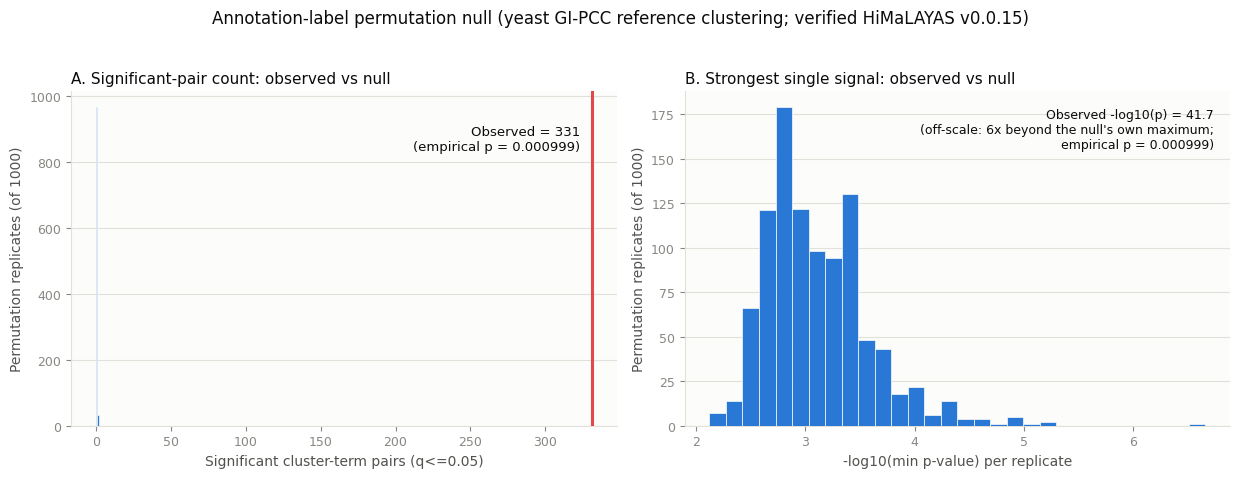

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/20_annotation_permutation_null/null_vs_observed.png


In [12]:
import matplotlib.pyplot as plt

CATEGORICAL_PALETTE = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"


def style_axis(ax):
    ax.set_facecolor("#fcfcfb")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRIDLINE)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
style_axis(ax)
ax.hist(
    null_distribution["n_sig"],
    bins=range(0, max(int(null_distribution["n_sig"].max()) + 2, 10)),
    color=CATEGORICAL_PALETTE[0],
    edgecolor="#fcfcfb",
    linewidth=0.5,
    zorder=3,
)
ax.axvline(OBSERVED_N_SIG, color=CATEGORICAL_PALETTE[7], linewidth=2.2, zorder=4)
ax.annotate(
    f"Observed = {OBSERVED_N_SIG}\n(empirical p = {empirical_p_n_sig:.3g})",
    xy=(OBSERVED_N_SIG, ax.get_ylim()[1] * 0.9),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="top",
    fontsize=9.5,
    color=INK_PRIMARY,
)
ax.set_xlabel("Significant cluster-term pairs (q<=0.05)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(f"Permutation replicates (of {N_PERMUTATIONS})", color=INK_SECONDARY, fontsize=10)
ax.set_title(
    "A. Significant-pair count: observed vs null", color=INK_PRIMARY, fontsize=11, loc="left"
)

ax = axes[1]
style_axis(ax)
neg_log10_null = -np.log10(null_distribution["min_pval"].clip(lower=1e-300))
ax.hist(
    neg_log10_null,
    bins=30,
    color=CATEGORICAL_PALETTE[0],
    edgecolor="#fcfcfb",
    linewidth=0.5,
    zorder=3,
)
null_max_neg_log10 = float(neg_log10_null.max())
observed_neg_log10 = -np.log10(max(OBSERVED_MIN_PVAL, 1e-300))
ax.annotate(
    f"Observed -log10(p) = {observed_neg_log10:.1f}\n"
    f"(off-scale: {observed_neg_log10 / null_max_neg_log10:.0f}x beyond the null's own maximum;\n"
    f"empirical p = {empirical_p_min_pval:.3g})",
    xy=(0.97, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=9,
    color=INK_PRIMARY,
)
ax.set_xlabel("-log10(min p-value) per replicate", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(f"Permutation replicates (of {N_PERMUTATIONS})", color=INK_SECONDARY, fontsize=10)
ax.set_title(
    "B. Strongest single signal: observed vs null", color=INK_PRIMARY, fontsize=11, loc="left"
)

fig.suptitle(
    "Annotation-label permutation null (yeast GI-PCC reference clustering; verified HiMaLAYAS v0.0.15)",
    color=INK_PRIMARY,
    fontsize=12,
    y=1.03,
)
fig.tight_layout()
null_vs_observed_path = NB_FIGURES_DIR / "null_vs_observed.png"
fig.savefig(null_vs_observed_path, dpi=200, bbox_inches="tight", facecolor="#fcfcfb")
plt.show()
print(f"Saved {null_vs_observed_path}")

## 11. GO / CONDITIONAL_GO / CONCERN decision

Decision rule (this notebook's brief), driven by the *worse* (more conservative) of the two empirical p-values:

- **GO**: the worse empirical p-value sits at the resolution floor (`1/(N_PERMUTATIONS+1)`) -- no permutation replicate, out of 1000, ever matched or exceeded the observed signal on either metric.
- **CONDITIONAL_GO**: the worse empirical p-value is small but not at the floor (0 < p <= 0.05) -- observed signal is above null, but a handful of permutations came close or matched.
- **CONCERN**: the worse empirical p-value exceeds 0.05 -- random label permutations produce comparable significant-annotation counts or top signals.

In [13]:
floor_pvalue = 1 / (N_PERMUTATIONS + 1)
worst_empirical_p = max(empirical_p_n_sig, empirical_p_min_pval)

print(f"empirical_p (n_sig):     {empirical_p_n_sig:.3g}")
print(f"empirical_p (min_pval):  {empirical_p_min_pval:.3g}")
print(f"resolution floor:        {floor_pvalue:.3g}  (1 / (N_PERMUTATIONS + 1))")
print(f"worst (governing) empirical p-value: {worst_empirical_p:.3g}")

if worst_empirical_p <= floor_pvalue:
    decision = "GO"
elif worst_empirical_p <= 0.05:
    decision = "CONDITIONAL_GO"
else:
    decision = "CONCERN"

print(f"\nDECISION: {decision}")

empirical_p (n_sig):     0.000999
empirical_p (min_pval):  0.000999
resolution floor:        0.000999  (1 / (N_PERMUTATIONS + 1))
worst (governing) empirical p-value: 0.000999

DECISION: GO


## 12. Assemble and write manifest

In [14]:
flags = list(input_hash_flags)
if activation is None:
    flags.append(f"HIMALAYAS ACTIVATION FAILED: {activation_error}")

if decision == "GO":
    next_action = (
        "Proceed to 21_cluster_randomization_null.ipynb. Observed cluster-term enrichment "
        f"({OBSERVED_N_SIG} significant pairs, min p={OBSERVED_MIN_PVAL:.2e}) is beaten by "
        f"none of {N_PERMUTATIONS} annotation-label permutation nulls on either metric "
        "(empirical p at the resolution floor); the signal is not an artifact of the true "
        "gene-to-GO annotation mapping under the fixed reference clustering. Notebook 21 "
        "next tests whether the clustering itself could reproduce comparable enrichment "
        "from an arbitrary same-size gene partition."
    )
elif decision == "CONDITIONAL_GO":
    next_action = (
        "Proceed to 21_cluster_randomization_null.ipynb, but note the annotation-label null "
        f"is favorable-but-not-dramatic (worst empirical p={worst_empirical_p:.3g}); frame "
        "enrichment strength claims accordingly and lean on notebook 21's cluster-"
        "randomization null for a second, independent check before broad claims (frozen "
        "plan Section 4)."
    )
else:
    next_action = (
        "PAUSE manuscript polish. Random annotation-label permutations produce comparable "
        f"significant-pair counts or top signal to the observed data (worst empirical "
        f"p={worst_empirical_p:.3g}). Reconsider claims, figures, or venue before investing "
        "further time (frozen plan Section 4, No-Go response)."
    )

manifest = {
    "notebook": "20_annotation_permutation_null.ipynb",
    "status": "COMPLETE" if activation is not None else "BLOCKED",
    "decision": decision,
    "next_action": next_action,
    "generated_at_utc": ru.utc_timestamp(),
    "repo_root": str(layout["repo_root"]),
    "himalayas_source": activation if activation is not None else {"error": activation_error},
    "himalayas_diagnostics_at_start": himalayas_diag_before,
    "input_files": {
        "gi_pcc_matrix": {
            "path": "data/yeast/gi_pcc_sampled.tsv",
            "sha256": current_hashes["data/yeast/gi_pcc_sampled.tsv"],
            "matches_nb00_record": current_hashes["data/yeast/gi_pcc_sampled.tsv"]
            == recorded_hashes.get("data/yeast/gi_pcc_sampled.tsv"),
        },
        "go_bp_annotations": {
            "path": "data/yeast/go_bp_name_to_orfs.json",
            "sha256": current_hashes["data/yeast/go_bp_name_to_orfs.json"],
            "matches_nb00_record": current_hashes["data/yeast/go_bp_name_to_orfs.json"]
            == recorded_hashes.get("data/yeast/go_bp_name_to_orfs.json"),
        },
    },
    "reference_config": {
        "linkage_method": LINKAGE_METHOD,
        "linkage_metric": LINKAGE_METRIC,
        "linkage_threshold": REFERENCE_THRESHOLD,
        "optimal_ordering": OPTIMAL_ORDERING,
        "min_cluster_size": REFERENCE_MIN_SIZE,
        "min_overlap": MIN_OVERLAP,
        "qval_cutoff": QVAL_CUTOFF,
    },
    "reference_reproduction_check": {
        "matches_nb01_nb10_nb11_baseline": bool(reproduction_matches),
        "results_rows": len(reference_results.df),
        "results_sig_rows": OBSERVED_N_SIG,
        "n_clusters": len(reference_cluster_labels),
        "n_annotation_terms": OBSERVED_N_TERMS,
        "observed_min_pval": OBSERVED_MIN_PVAL,
    },
    "permutation_design": {
        "method": (
            "Single uniform random permutation of the fixed 1053-gene matrix universe per "
            "replicate, applied to relabel every GO term's gene set (bijective -- preserves "
            "exact term sizes, cluster sizes, enrichment universe N, and real co-annotation "
            "structure). Clustering is held fixed; only enrichment is rerun per replicate."
        ),
        "n_permutations": N_PERMUTATIONS,
        "default_random_seed": DEFAULT_RANDOM_SEED,
        "seed_rule": "seed = DEFAULT_RANDOM_SEED + i for i in range(N_PERMUTATIONS)",
        "first_seed": PERMUTATION_SEEDS[0],
        "last_seed": PERMUTATION_SEEDS[-1],
    },
    "observed_vs_null": {
        "n_sig": {
            "observed": OBSERVED_N_SIG,
            "null_mean": float(null_distribution["n_sig"].mean()),
            "null_max": int(null_distribution["n_sig"].max()),
            "empirical_pvalue": empirical_p_n_sig,
        },
        "min_pval": {
            "observed": OBSERVED_MIN_PVAL,
            "null_mean": float(null_distribution["min_pval"].mean()),
            "null_min": float(null_distribution["min_pval"].min()),
            "empirical_pvalue": empirical_p_min_pval,
        },
        "resolution_floor": floor_pvalue,
        "worst_empirical_pvalue": worst_empirical_p,
    },
    "flags": flags,
    "outputs": {
        "tables": table_paths,
        "figures": {
            "null_vs_observed.png": str(null_vs_observed_path.relative_to(layout["repo_root"]))
        },
    },
    "interpretation": (
        f"Decision={decision}. Observed {OBSERVED_N_SIG} significant cluster-term pairs "
        f"(q<=0.05) vs a null distribution over {N_PERMUTATIONS} annotation-label "
        f"permutations: {n_sig_breakdown} significant pair(s), with no replicate exceeding "
        f"{int(null_distribution['n_sig'].max())} (empirical p={empirical_p_n_sig:.3g}). "
        f"Observed minimum p-value {OBSERVED_MIN_PVAL:.2e} vs null "
        f"range [{null_distribution['min_pval'].min():.2e}, {null_distribution['min_pval'].max():.2e}] "
        f"(empirical p={empirical_p_min_pval:.3g}). Per-cluster check: no reference cluster's "
        "headline annotation was ever significant by chance across all permutation replicates "
        "for that cluster (see per_cluster_null_check.csv). Enrichment on the true gene-to-GO "
        "mapping is not reproducible by randomly relabeling which gene carries which "
        "annotation, under the fixed reference clustering from fig_1.ipynb. This addresses "
        "annotation-label artifacts specifically; it does not test whether the clustering "
        "itself (an arbitrary same-size gene partition) could produce comparable enrichment "
        "-- that is the scope of notebook 21 (cluster randomization null)."
    ),
}

manifest_path = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, manifest_path)
print(f"Manifest written to: {manifest_path}")

reloaded = json.loads(manifest_path.read_text())
assert reloaded == json.loads(json.dumps(manifest, default=str)), "manifest round-trip mismatch"
print("Manifest JSON round-trip verified.")

Manifest written to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/20_annotation_permutation_null_manifest.json
Manifest JSON round-trip verified.


## 13. Readiness summary

In [15]:
print("=" * 72)
print(f"DECISION -- {NB_ID}")
print("=" * 72)
print(f"status:      {manifest['status']}")
print(f"decision:    {manifest['decision']}")
print(f"next_action: {manifest['next_action']}")
print()
print(
    f"HiMaLAYAS source: {activation['activated_version'] if activation else 'N/A'} "
    f"(verified tag {PINNED_TAG}, not the active dev install)"
)
print(f"Reference reproduction matches notebooks 01/10/11: {reproduction_matches}")
print()
print("Observed vs null summary:")
display(observed_vs_null_summary)
print()
print("Per-cluster 'significant by chance' rate (should be ~0 for a real signal):")
display(per_cluster_null_check[["ref_cluster_id", "ref_top_term", "rate_significant_by_chance"]])
print()
print(f"Manifest:  {manifest_path}")
print(f"Tables:    {NB_TABLES_DIR}")
print(f"Figures:   {NB_FIGURES_DIR}")

DECISION -- 20_annotation_permutation_null
status:      COMPLETE
decision:    GO
next_action: Proceed to 21_cluster_randomization_null.ipynb. Observed cluster-term enrichment (331 significant pairs, min p=1.80e-42) is beaten by none of 1000 annotation-label permutation nulls on either metric (empirical p at the resolution floor); the signal is not an artifact of the true gene-to-GO annotation mapping under the fixed reference clustering. Notebook 21 next tests whether the clustering itself could reproduce comparable enrichment from an arbitrary same-size gene partition.

HiMaLAYAS source: 0.0.15 (verified tag v0.0.15, not the active dev install)
Reference reproduction matches notebooks 01/10/11: True

Observed vs null summary:


,metric,observed_value,null_mean,null_median,null_std,null_min,null_max,empirical_pvalue
0,n_significant_cluster_term_pairs (q<=0.05),3.310000e+02,0.033000,0.000000,0.178726,0.000000e+00,1.000000,0.000999
1,min_pval (strongest single cluster-term signal),1.798541e-42,0.001214,0.000944,0.001020,2.199741e-07,0.007558,0.000999



Per-cluster 'significant by chance' rate (should be ~0 for a real signal):


,ref_cluster_id,ref_top_term,rate_significant_by_chance
0,1,GPI anchor biosynthetic process,0.0
1,2,vesicle-mediated transport,0.0
2,3,"mRNA splicing, via spliceosome",0.0
3,4,cytoplasmic translation,0.0
4,5,mitochondrial respiratory chain complex IV ass...,0.0
5,6,DNA replication,0.0
6,7,cell division,0.0



Manifest:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/20_annotation_permutation_null_manifest.json
Tables:    /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/20_annotation_permutation_null
Figures:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/20_annotation_permutation_null
